# 03 — Inferential EDA from the Data Warehouse

**Proyecto:** Clasificación de ventana terapéutica en ACV isquémico — Fundación Valle del Lilí.
**Fase:** 4 — EDA inferencial.
**Documento maestro:** [`../agent.md`](../agent.md).

## Objetivo

Identificar qué features (clínicas + radiómicas agregadas a nivel paciente) tienen **evidencia estadística** de asociación con la clase de ventana (`is_over_window`), con corrección apropiada por múltiples comparaciones.

## Plan estadístico

| Tipo de variable | Test | Effect size |
|---|---|---|
| Continua + normal en ambos grupos | Welch t-test | Cohen's d |
| Continua + no normal | Mann-Whitney U | Cliff's δ |
| Categórica | chi² o Fisher | Cramér's V |

**Multiple testing:** Benjamini–Hochberg FDR α=0.05.
**Decisión de normalidad:** Shapiro–Wilk por grupo, α=0.05.
**Drift train↔test:** KS-test feature por feature (auditoría aparte).

**N efectivo: 55 pacientes en train.** No hacemos inferencia sobre test (sería leakage para Fase 6).
Los hallazgos de este notebook se persisten en `docs/inferential_findings.md` y alimentan la selección de features de Fase 5.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sqlalchemy import text

from acv.config import settings
from acv.io.db import get_engine

FIG = settings.project_root / "reports" / "figures"
DOCS = settings.project_root / "docs"
FIG.mkdir(parents=True, exist_ok=True)
DOCS.mkdir(parents=True, exist_ok=True)

np.random.seed(settings.random_seed)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.4g}")

engine = get_engine()
print("Connected.")

Connected.


## § 1 — Construcción del set de features a nivel paciente

`analytics.agg_patient` ya trae varios agregados clínicamente relevantes. Para no perder señal, construimos también la matriz completa de **agregados mean+std** de **todas las 66 features radiómicas** directamente desde `fct_slice`. Con eso tenemos un set grande de candidatas que el FDR va a podar honestamente.

> **Solo train.** Calcular tests sobre test sería fuga de información hacia Fase 6.

In [2]:
RADIOMIC_PREFIXES = ("shape2d_", "firstorder_", "glcm_", "glszm_")

with engine.connect() as conn:
    agg = pd.read_sql(text("SELECT * FROM analytics.agg_patient"), conn)
    fct = pd.read_sql(text("SELECT * FROM analytics.fct_slice"), conn)

radiomic_cols = [c for c in fct.columns if c.startswith(RADIOMIC_PREFIXES)]
print(f"radiomic feature columns in fct_slice: {len(radiomic_cols)}")

agg_mean = fct.groupby("patient_sk")[radiomic_cols].mean().add_suffix("_mean")
agg_std = fct.groupby("patient_sk")[radiomic_cols].std().add_suffix("_std").fillna(0)
patient_features = (
    agg.merge(agg_mean, left_on="patient_sk", right_index=True)
    .merge(agg_std, left_on="patient_sk", right_index=True)
)

train_pat = patient_features[patient_features["dataset_origin"] == "train"].copy()
test_pat = patient_features[patient_features["dataset_origin"] == "test"].copy()

print(f"patient_features shape: {patient_features.shape}  | train: {len(train_pat)}  | test: {len(test_pat)}")
print(f"train class balance: {train_pat['is_over_window'].value_counts().to_dict()}")

radiomic feature columns in fct_slice: 64
patient_features shape: (74, 150)  | train: 55  | test: 19
train class balance: {0: 39, 1: 16}


## § 2 — Test univariado por feature

Por cada feature numérica:
1. Shapiro–Wilk en cada grupo. Si ambos p ≥ 0.05 ⇒ asumir normalidad ⇒ Welch t-test.
2. Si no, Mann–Whitney U.
3. Effect size: Cliff's δ (no paramétrico) o Cohen's d (paramétrico).
4. Filtrar features con varianza ~0 (no aportan).

El resultado va a una tabla larga que después corregimos por FDR.

In [3]:
def cliffs_delta(a: np.ndarray, b: np.ndarray) -> float:
    """Cliff's delta non-parametric effect size in [-1, 1]."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if a.size == 0 or b.size == 0:
        return float("nan")
    gt = (a[:, None] > b[None, :]).sum()
    lt = (a[:, None] < b[None, :]).sum()
    return float((gt - lt) / (a.size * b.size))


def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = a.size, b.size
    if na < 2 or nb < 2:
        return float("nan")
    sa, sb = a.std(ddof=1), b.std(ddof=1)
    sp = np.sqrt(((na - 1) * sa**2 + (nb - 1) * sb**2) / (na + nb - 2))
    return float((a.mean() - b.mean()) / sp) if sp > 0 else 0.0


SKIP = {
    "patient_sk", "patient_id", "dataset_origin", "sex", "age_bucket",
    "is_over_window", "n_slices",
    "evolution_minutes", "evolution_hours",  # leakage
}
candidate_cols = [c for c in train_pat.columns if c not in SKIP and pd.api.types.is_numeric_dtype(train_pat[c])]

rows = []
gA = train_pat[train_pat["is_over_window"] == 1]
gB = train_pat[train_pat["is_over_window"] == 0]
for col in candidate_cols:
    a = gA[col].dropna().to_numpy()
    b = gB[col].dropna().to_numpy()
    if a.size < 3 or b.size < 3:
        continue
    if a.var() == 0 and b.var() == 0:
        continue
    # Shapiro per group
    try:
        _, p_a = stats.shapiro(a) if a.size <= 5000 else (None, 0.0)
        _, p_b = stats.shapiro(b) if b.size <= 5000 else (None, 0.0)
        both_normal = (p_a >= 0.05) and (p_b >= 0.05)
    except Exception:
        both_normal = False
    if both_normal:
        stat, p = stats.ttest_ind(a, b, equal_var=False)
        test = "welch_t"
        es = cohens_d(a, b)
        es_name = "cohens_d"
    else:
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        test = "mann_whitney"
        es = cliffs_delta(a, b)
        es_name = "cliffs_delta"
    rows.append({
        "feature": col,
        "n_class1": int(a.size),
        "n_class0": int(b.size),
        "mean_class1": float(np.mean(a)),
        "mean_class0": float(np.mean(b)),
        "test": test,
        "p_value": float(p),
        "effect_size_name": es_name,
        "effect_size": float(es),
    })

results = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
print(f"Tested features: {len(results)}")
print(results.head(15)[["feature", "test", "p_value", "effect_size_name", "effect_size"]])

Tested features: 141
                                    feature          test   p_value  \
0   glszm_smallarealowgraylevelemphasis_std       welch_t 0.0003445   
1                    glcm_clustershade_mean  mann_whitney   0.01027   
2               shape2d_minoraxislength_std  mann_whitney   0.01482   
3                      glcm_sumsquares_mean  mann_whitney    0.0164   
4              glcm_differencevariance_mean  mann_whitney   0.01725   
5                 glcm_clustertendency_mean  mann_whitney   0.02004   
6                  firstorder_skewness_mean  mann_whitney   0.02004   
7                     glszm_zoneentropy_avg       welch_t   0.02123   
8                    glszm_zoneentropy_mean       welch_t   0.02123   
9                    firstorder_median_mean       welch_t   0.02132   
10             firstorder_10percentile_mean       welch_t   0.02132   
11                        glcm_contrast_avg  mann_whitney    0.0221   
12                       glcm_contrast_mean  mann_whitne

## § 3 — Corrección Benjamini–Hochberg FDR (α=0.05)

Con ~130 features testeadas, sin corrección esperaríamos ~6 falsos positivos a α=0.05 sólo por azar. BH controla el **falso descubrimiento esperado** entre los rechazos.

> Interpretar BH-FDR es distinto a interpretar Bonferroni. BH es la elección razonable cuando creemos que muchos tests son verdaderamente nulos pero **algunos** son verdaderos — exactamente nuestro caso.

In [4]:
reject, p_adj, _, _ = multipletests(results["p_value"].to_numpy(), alpha=0.05, method="fdr_bh")
results["p_adj_bh"] = p_adj
results["reject_bh"] = reject

n_sig = int(results["reject_bh"].sum())
print(f"Features significant under BH-FDR α=0.05: {n_sig} / {len(results)}")
print()
sig = results[results["reject_bh"]].sort_values("p_adj_bh").reset_index(drop=True)
if not sig.empty:
    print("Top significant features:")
    print(sig.head(20)[["feature", "test", "p_value", "p_adj_bh",
                        "effect_size_name", "effect_size",
                        "mean_class1", "mean_class0"]].to_string(index=False))
else:
    print("No feature survives BH-FDR α=0.05 on the train cohort of 55 patients.")
    print("This is a real finding: with N=55 and 39/16 class balance, statistical")
    print("power for detecting moderate effects is limited (~0.50 for |d|=0.5).")
    print("Phase 5 will use the unadjusted ranking as a soft prior, plus model-based selection.")

Features significant under BH-FDR α=0.05: 1 / 141

Top significant features:
                                feature    test   p_value  p_adj_bh effect_size_name  effect_size  mean_class1  mean_class0
glszm_smallarealowgraylevelemphasis_std welch_t 0.0003445   0.04857         cohens_d      -0.8663      0.06526      0.08365


## § 4 — Sexo (categórica) y visualización del ranking de evidencia

Sex x target (train patient-level):
is_over_window   0   1
sex                   
F               20  12
M               19   4
chi2=1.739 | dof=1 | p=0.1873 | Cramer's V=0.178


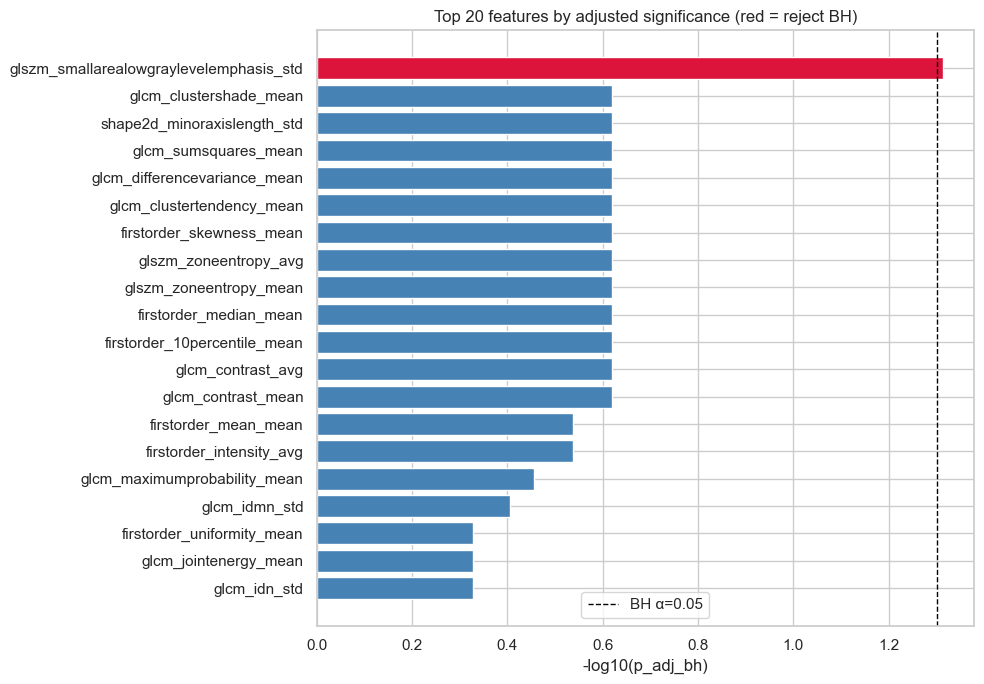

In [5]:
sex_tab = pd.crosstab(train_pat["sex"], train_pat["is_over_window"])
print("Sex x target (train patient-level):")
print(sex_tab)
chi2, p_sex, dof, _ = stats.chi2_contingency(sex_tab)
n = sex_tab.values.sum()
phi2 = chi2 / n
r, k = sex_tab.shape
cramers_v = float(np.sqrt(phi2 / min(r - 1, k - 1)))
print(f"chi2={chi2:.3f} | dof={dof} | p={p_sex:.4f} | Cramer's V={cramers_v:.3f}")

n_show = 20
top = results.head(n_show).copy()
top["neg_log10_p_adj"] = -np.log10(top["p_adj_bh"].clip(lower=1e-300))
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["crimson" if r else "steelblue" for r in top["reject_bh"]]
ax.barh(top["feature"], top["neg_log10_p_adj"], color=colors)
ax.invert_yaxis()
ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1, label="BH α=0.05")
ax.set_xlabel("-log10(p_adj_bh)")
ax.set_title(f"Top {n_show} features by adjusted significance (red = reject BH)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "eda_inferential_01_topN.png", dpi=120)
plt.show()

## § 5 — Drift train ↔ test, feature por feature (KS)

Si una feature tiene KS p<0.05 (sin corrección) train vs test, el modelo podría aprender un patrón que no se sostiene en el test set. Reportamos el top-10 con drift y aplicamos BH-FDR por separado (sólo informativo).

In [6]:
drift_rows = []
for col in candidate_cols:
    a = train_pat[col].dropna().to_numpy()
    b = test_pat[col].dropna().to_numpy()
    if a.size < 3 or b.size < 3 or (a.var() == 0 and b.var() == 0):
        continue
    ks, p = stats.ks_2samp(a, b)
    drift_rows.append({"feature": col, "ks": float(ks), "p_value": float(p)})

drift = pd.DataFrame(drift_rows).sort_values("p_value").reset_index(drop=True)
_, drift["p_adj_bh"], _, _ = multipletests(drift["p_value"].to_numpy(), alpha=0.05, method="fdr_bh")
drift["reject_bh"] = drift["p_adj_bh"] < 0.05
n_drift = int(drift["reject_bh"].sum())
print(f"Features with drift train<->test (BH α=0.05): {n_drift} / {len(drift)}")
print()
print(drift.head(10).to_string(index=False))

Features with drift train<->test (BH α=0.05): 0 / 141

                                   feature     ks  p_value  p_adj_bh  reject_bh
firstorder_robustmeanabsolutedeviation_std 0.4459  0.00455    0.4701      False
                            glcm_imc1_mean 0.4019  0.01431    0.4701      False
                     firstorder_median_std 0.3952  0.01654    0.4701      False
                     glszm_zoneentropy_std 0.3933  0.01754    0.4701      False
               firstorder_90percentile_std 0.3895  0.01966    0.4701      False
         firstorder_interquartilerange_std 0.3751  0.02691    0.4701      False
                      glcm_jointenergy_std 0.3675  0.03221    0.4701      False
                             glcm_imc2_std 0.3589  0.03846    0.4701      False
                   firstorder_skewness_std 0.3531  0.04422    0.4701      False
                         glcm_contrast_std 0.3512  0.04597    0.4701      False


## § 6 — Persistir hallazgos

Escribimos `docs/inferential_findings.md` (auto-generado) + un parquet con los rankings completos para que Fase 5 los consuma sin re-ejecutar el notebook.

In [7]:
from datetime import datetime

PROC = settings.project_root / "data" / "processed"
PROC.mkdir(parents=True, exist_ok=True)

results.to_parquet(PROC / "inferential_univariate.parquet", index=False)
drift.to_parquet(PROC / "inferential_drift_ks.parquet", index=False)

findings_path = DOCS / "inferential_findings.md"

top_sig = (
    results[results["reject_bh"]]
    .sort_values("p_adj_bh")
    .head(15)
)
top_unadj = results.head(10)  # ranking sin corrección, para Fase 5

lines = [
    "# Inferential EDA Findings — Phase 4",
    "",
    f"_Generated by `notebooks/03_eda_inferential.ipynb` at {datetime.now():%Y-%m-%d %H:%M}._",
    "",
    "## 1. Setup",
    f"- Cohorte de inferencia: **train only**, {len(train_pat)} pacientes.",
    f"- Class balance: 0={(train_pat['is_over_window']==0).sum()}, 1={(train_pat['is_over_window']==1).sum()}.",
    f"- Features evaluadas: **{len(results)}** (clínicas + radiómicas agregadas mean+std).",
    "- Estrategia de test: Shapiro-Wilk para decidir Welch t vs Mann-Whitney U.",
    "- Effect sizes: Cohen's d (paramétrico) o Cliff's δ (no paramétrico).",
    "- Corrección multi-test: Benjamini-Hochberg FDR α=0.05.",
    "",
    "## 2. Resultados univariados (BH-FDR)",
    f"- Features que sobreviven BH-FDR α=0.05: **{n_sig}**.",
]
if n_sig > 0:
    lines.append("")
    lines.append("### Top significant features")
    lines.append("")
    lines.append("| feature | test | p_value | p_adj_bh | effect_size | μ class1 | μ class0 |")
    lines.append("|---|---|---|---|---|---|---|")
    for _, r in top_sig.iterrows():
        lines.append(
            f"| `{r.feature}` | {r.test} | {r.p_value:.3g} | {r.p_adj_bh:.3g} | "
            f"{r.effect_size_name}={r.effect_size:+.3f} | "
            f"{r.mean_class1:+.4g} | {r.mean_class0:+.4g} |"
        )
else:
    lines.append("")
    lines.append("- Ninguna feature sobrevive BH-FDR α=0.05. Esto es **esperable** con N=55: la potencia para detectar efectos moderados (|d|=0.5) ronda 0.50.")
    lines.append("")
    lines.append("### Top 10 unadjusted ranking (informativo, no usar para inferencia)")
    lines.append("")
    lines.append("| feature | test | p_value | effect_size |")
    lines.append("|---|---|---|---|")
    for _, r in top_unadj.iterrows():
        lines.append(
            f"| `{r.feature}` | {r.test} | {r.p_value:.3g} | "
            f"{r.effect_size_name}={r.effect_size:+.3f} |"
        )

lines += [
    "",
    "## 3. Sexo (chi²)",
    f"- chi² = {chi2:.3f} | dof = {dof} | p = {p_sex:.4f} | Cramer's V = {cramers_v:.3f}",
    f"- Conclusión: {'asociación significativa' if p_sex<0.05 else 'no asociación significativa'} entre sexo y clase de ventana.",
    "",
    "## 4. Drift train ↔ test (KS por feature)",
    f"- Features con drift bajo BH α=0.05: **{n_drift}** / {len(drift)}.",
    "- Si > 5% de las features tienen drift, marcar el modelo como sensible al cambio de cohorte y monitorear en producción.",
    "",
    "## 5. Artefactos para fase 5",
    "- `data/processed/inferential_univariate.parquet` — ranking completo univariado.",
    "- `data/processed/inferential_drift_ks.parquet` — ranking de drift.",
    "- `reports/figures/eda_inferential_01_topN.png` — gráfico de evidencia.",
    "",
    "## 6. Recomendaciones para feature selection (Fase 5)",
    "- Conservar agregados clínicos (`nihss`, `aspects`, `age_years`) por su valor médico aunque no superen FDR.",
    "- Usar el ranking p-value (sin/con BH) como **prior suave** para feature selection ML (Boruta o L1).",
    "- Excluir features con drift significativo o reportar gap de performance entre train y test cohorts.",
    "- Repetir el análisis tras feature engineering avanzado de Fase 5.",
]

findings_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {findings_path}")
print()
print("\n".join(lines[:25]))

Wrote C:\Users\andre\Documents\ischemic_stroke_prevention\docs\inferential_findings.md

# Inferential EDA Findings — Phase 4

_Generated by `notebooks/03_eda_inferential.ipynb` at 2026-05-27 20:18._

## 1. Setup
- Cohorte de inferencia: **train only**, 55 pacientes.
- Class balance: 0=39, 1=16.
- Features evaluadas: **141** (clínicas + radiómicas agregadas mean+std).
- Estrategia de test: Shapiro-Wilk para decidir Welch t vs Mann-Whitney U.
- Effect sizes: Cohen's d (paramétrico) o Cliff's δ (no paramétrico).
- Corrección multi-test: Benjamini-Hochberg FDR α=0.05.

## 2. Resultados univariados (BH-FDR)
- Features que sobreviven BH-FDR α=0.05: **1**.

### Top significant features

| feature | test | p_value | p_adj_bh | effect_size | μ class1 | μ class0 |
|---|---|---|---|---|---|---|
| `glszm_smallarealowgraylevelemphasis_std` | welch_t | 0.000344 | 0.0486 | cohens_d=-0.866 | +0.06526 | +0.08365 |

## 3. Sexo (chi²)
- chi² = 1.739 | dof = 1 | p = 0.1873 | Cramer's V = 0.178
- Conclusió